# EVA Hardware Artifact Reproduction Notebook

This notebook visualizes the simulation outputs and reproduces all paper-facing hardware tables and figures.

**Prerequisites**: Run the CLI studies described in `README.md` before executing this notebook. Use the `eva` Jupyter kernel.


In [63]:
# --- Imports, path resolution, shared constants, and helper functions ---

from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use('ggplot')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'simulator').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError(
        'Could not resolve the Eva repository root from the current working directory. '
        'Open this notebook from inside the Eva repository or its notebooks directory.'
    )


repo_root = resolve_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from simulator.plotting import plot_fig9_from_aggregated_csv

# Output directories produced by the CLI studies
simulator_root = repo_root / 'simulator'
fig9_root = simulator_root / 'output' / 'fig9_fc'
non_e2e_root = simulator_root / 'output'
e2e_root = simulator_root / 'output' / 'e2e' / 'full'
export_root = simulator_root / 'output' / 'notebook_exports'
export_root.mkdir(parents=True, exist_ok=True)

# Display labels used throughout the notebook (internal key -> paper label)
METHOD_LABELS = {
    'systolic_array': 'SA',
    'ant': 'ANT',
    'figna': 'FIGNA',
    'figlut_4': 'FIGLUT',
    'vqarray_4_decode': 'EVA-W4',
    'vqarray_3_decode': 'EVA-W3',
    'vqarray_2_decode': 'EVA-W2',
    'vqarray_2_gptvq_decode': 'GPT-W2*',
}
PAPER_METHOD_ORDER = ['SA', 'ANT', 'FIGNA', 'FIGLUT', 'EVA-W4', 'EVA-W3', 'EVA-W2', 'GPT-W2*']
DENSE_FIGURE_ORDER = ['SA', 'ANT', 'FIGNA', 'FIGLUT', 'EVA-W4', 'EVA-W3', 'EVA-W2']
MODEL_LABELS = {
    'llama_7b': 'LLaMA-7B',
    'llama_13b': 'LLaMA-13B',
    'llama_2_7b': 'LLaMA-2-7B',
    'llama_2_13b': 'LLaMA-2-13B',
    'llama_30b': 'LLaMA-30B',
    'llama_65b': 'LLaMA-65B',
    'llama3_8b': 'LLaMA-3-8B',
    'llama_3_1_8b': 'LLaMA-3.1-8B',
    'llama_3_2_1b': 'LLaMA-3.2-1B',
    'deepseek_r1_distill_llama_8b': 'DeepSeek-R1-Distill-LLaMA-8B',
    'mixtral_8x7b': 'Mixtral-8x7B',
    'qwen3_30b_a3b': 'Qwen3-30B-A3B',
}
# Consistent colors for each method across all figures
COLOR_MAP = {
    'SA': '#5aa6a5',
    'ANT': '#8ec1bc',
    'FIGNA': '#d9ebcf',
    'FIGLUT': '#b8d7f0',
    'EVA-W4': '#e87663',
    'EVA-W3': '#f39a8a',
    'EVA-W2': '#f4b266',
    'GPT-W2*': '#7a3417',
    'EVA-A8W8': '#7a3417',
    'SA-A8W8': '#5aa6a5',
    'ANT-A8W8': '#8ec1bc',
    'FIGNA-A16W4': '#d9ebcf',
    'FIGLUT-A16W4': '#b8d7f0',
    'EVA-A16W4': '#e87663',
    'EVA-A16W3': '#f39a8a',
    'EVA-A16W2': '#f4b266',
}
TABLE_VII_ORDER = ['VQ_conflict', 'VQ_LLM 0.5', 'OS_SA', 'EVA 4x8', 'EVA 32x8', 'EVA scale x 4']
TABLE_VII_LABELS = {
    'VQ_conflict': 'VQ w. Conflict',
    'VQ_LLM 0.5': 'VQ-LLM',
    'OS_SA': 'VQ w/o. Conflict',
    'EVA 4x8': 'EVA EU-4 x 1',
    'EVA 32x8': 'EVA EU-32 x 1',
    'EVA scale x 4': 'EVA EU-32 x 4',
}
TABLE_VII_METADATA = {
    'Code Book SRAM Size': {
        'VQ_conflict': '8 x 256 x FP16 = 4KB',
        'VQ_LLM 0.5': '8 x 256 x FP16 x 2.5 = 10KB',
        'OS_SA': '8 x 256 x FP16 x 4 = 16KB',
        'EVA 4x8': '1 x 256 x FP16 x 4 = 2KB',
        'EVA 32x8': '1 x 256 x FP16 x 32 = 16KB',
        'EVA scale x 4': '1 x 256 x FP16 x 32 x 4 = 64KB',
    },
    'Code Book SRAM Bandwidth': {
        'VQ_conflict': '64 B/Cycle',
        'VQ_LLM 0.5': '64 B/Cycle',
        'OS_SA': '64 B/Cycle',
        'EVA 4x8': '8 B/Cycle',
        'EVA 32x8': '64 B/Cycle',
        'EVA scale x 4': '256 B/Cycle',
    },
    'Systolic Array Size': {entry: '32x8 (FP16)' for entry in TABLE_VII_ORDER},
    'Epilogue Unit Size': {
        'VQ_conflict': '-',
        'VQ_LLM 0.5': '-',
        'OS_SA': '-',
        'EVA 4x8': '4-input Adder',
        'EVA 32x8': '32-input Adder',
        'EVA scale x 4': '4 x 32-input Adders',
    },
    'Note': {
        'VQ_conflict': 'Full Conflicts',
        'VQ_LLM 0.5': '50% Conflicts',
        'OS_SA': 'No Conflicts',
        'EVA 4x8': 'No Conflicts',
        'EVA 32x8': 'No Conflicts',
        'EVA scale x 4': 'No Conflicts',
    },
}
TABLE_IX_METADATA = [
    {'method': 'vqarray_2_decode', 'Algorithm': 'AQLM 2x8', 'd': 8, 'n (2^n)': '8 (256)', 'C': 2, 'q': 2, 'N': 4096, 'PE:EU': '1:16'},
    {'method': 'vqarray_3_decode', 'Algorithm': 'AQLM 3x8', 'd': 8, 'n (2^n)': '8 (256)', 'C': 3, 'q': 3, 'N': 4096, 'PE:EU': '1:16'},
    {'method': 'vqarray_2_decode_12', 'Algorithm': 'AQLM 2x12', 'd': 8, 'n (2^n)': '12 (4096)', 'C': 2, 'q': 3, 'N': 4096, 'PE:EU': '1:1'},
    {'method': 'vqarray_4_decode', 'Algorithm': 'AQLM 4x8', 'd': 8, 'n (2^n)': '8 (256)', 'C': 4, 'q': 4, 'N': 4096, 'PE:EU': '1:16'},
    {'method': 'vqarray_1_decode_16', 'Algorithm': 'AQLM 1x16', 'd': 8, 'n (2^n)': '16 (65536)', 'C': 1, 'q': 2, 'N': 4096, 'PE:EU': '16:1'},
    {'method': 'vqarray_2_gptvq_decode', 'Algorithm': 'GPTVQ-4D', 'd': 4, 'n (2^n)': '8 (256)', 'C': 1, 'q': 2, 'N': 256, 'PE:EU': '1:1'},
    {'method': 'vqarray_1_decode_4d', 'Algorithm': 'Hypothesized', 'd': 4, 'n (2^n)': '8 (256)', 'C': 1, 'q': 2, 'N': 4096, 'PE:EU': '1:16'},
]

def require(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(path)
    return path

def save_table(df: pd.DataFrame, filename: str, index: bool = True) -> Path:
    path = export_root / filename
    df.to_csv(path, index=index)
    return path

def save_figure(fig: plt.Figure, filename: str) -> Path:
    path = export_root / filename
    fig.savefig(path, bbox_inches='tight')
    return path

def autopct_values(values):
    total = sum(values)
    def _formatter(pct):
        value = pct * total / 100.0
        return f'{value:.3f}'
    return _formatter

display(Markdown(f'Resolved repository root: `{repo_root}`  '))
display(Markdown(f'Notebook exports will be written to: `{export_root}`'))

Resolved repository root: `/home/bd199/eva_ae/Eva`  

Notebook exports will be written to: `/home/bd199/eva_ae/Eva/simulator/output/notebook_exports`

In [64]:
required_outputs = {
    'Fig. 9 aggregate CSV': fig9_root / 'aggregated_sequence1.csv',
    'TABLE VI': non_e2e_root / 'fig10_hw' / 'table_vi.csv',
    'Fig. 10 area breakdown': non_e2e_root / 'fig10_hw' / 'fig10_area_breakdown.csv',
    'Fig. 10 power breakdown': non_e2e_root / 'fig10_hw' / 'fig10_power_breakdown.csv',
    'Fig. 8 Num. EU report': non_e2e_root / 'fig8_dse' / 'fig8_num_eu.csv',
    'Fig. 8 decode bandwidth': non_e2e_root / 'fig8_dse' / 'fig8_memory_bandwidth_decode.csv',
    'Fig. 8 prefill bandwidth': non_e2e_root / 'fig8_dse' / 'fig8_memory_bandwidth_prefill.csv',
    'TABLE VII': non_e2e_root / 'table_vii_abl' / 'table_vii.csv',
    'TABLE VIII': non_e2e_root / 'table_viii_data' / 'table_viii.csv',
    'Fig. 14 histogram': non_e2e_root / 'fig14_index' / 'fig14_index_count_histogram_avg.csv',
    'Fig. 14 utilization': non_e2e_root / 'fig14_index' / 'fig14_unique_indices_per_tile_avg.csv',
    'TABLE IX': non_e2e_root / 'table_ix_vq' / 'table_ix.csv',
    'Fig. 11': non_e2e_root / 'fig11_batch' / 'fig11_batch_scaling.csv',
    'Fig. 12': e2e_root / 'fig12_llama2.csv',
    'Fig. 13': e2e_root / 'fig13_moe.csv',
}
missing = {label: path for label, path in required_outputs.items() if not path.exists()}
if missing:
    lines = ['Missing required study outputs. Run the CLI commands in README.md first:', '']
    lines.extend([f'- `{label}`: `{path}`' for label, path in missing.items()])
    raise RuntimeError('\n'.join(lines))
display(Markdown(f'All {len(required_outputs)} required output files found.'))

All 15 required output files found.

In [65]:
table_vi_raw = pd.read_csv(require(non_e2e_root / 'fig10_hw' / 'table_vi.csv')).set_index('architecture')
raw_vii = pd.read_csv(require(non_e2e_root / 'table_vii_abl' / 'table_vii.csv')).set_index('entry')
raw_viii = pd.read_csv(require(non_e2e_root / 'table_viii_data' / 'table_viii.csv'))
raw_viii = raw_viii[raw_viii['dataset'].isin(['arxiv', 'gsm8k'])].copy()
raw_ix = pd.read_csv(require(non_e2e_root / 'table_ix_vq' / 'table_ix.csv'))

table_vii_metadata = {
    'Code Book SRAM Size': {
        'VQ_conflict': '8 x 256 x\nFP16 =\n4KB',
        'VQ_LLM 0.5': '8 x 256 x\nFP16 x 2.5 =\n10KB',
        'OS_SA': '8 x 256 x\nFP16 x 4 =\n16KB',
        'EVA 4x8': '1 x 256 x\nFP16 x 4 =\n2KB',
        'EVA 32x8': '1 x 256 x\nFP16 x 32 =\n16KB',
        'EVA scale x 4': '1 x 256 x\nFP16 x 32 x 4 =\n64KB',
    },
    'Code Book SRAM Bandwidth': {
        'VQ_conflict': '4 bank x 8\nx FP16 =\n64 B/Cycle',
        'VQ_LLM 0.5': '4 bank x 8\nx FP16 =\n64 B/Cycle',
        'OS_SA': '4 bank x 8\nx FP16 =\n64 B/Cycle',
        'EVA 4x8': '4 bank x 1\nx FP16 =\n8 B/Cycle',
        'EVA 32x8': '32 bank x 1\nx FP16 =\n64 B/Cycle',
        'EVA scale x 4': '32 bank x 1\nx FP16 x 4 =\n256 B/Cycle',
    },
    'Systolic Array Size': {entry: '32x8 (FP16)' for entry in TABLE_VII_ORDER},
    'Epilogue Unit Size': {
        'VQ_conflict': '-',
        'VQ_LLM 0.5': '-',
        'OS_SA': '-',
        'EVA 4x8': '4-input\nAdder',
        'EVA 32x8': '32-input\nAdder',
        'EVA scale x 4': '4 x 32-Input\nAdders',
    },
    'Note': {
        'VQ_conflict': 'Full Conflicts',
        'VQ_LLM 0.5': '50% Conflicts',
        'OS_SA': 'No Conflicts',
        'EVA 4x8': 'No Conflicts',
        'EVA 32x8': 'No Conflicts',
        'EVA scale x 4': 'No Conflicts',
    },
}

## Tables and Figures
### TABLE VI -- Hardware Characterization
Area, power, throughput, and efficiency for EVA vs baselines (SA, ANT, FIGNA, FIGLUT) at 28nm 500MHz.

`python -m simulator.main --study fig10_hw --output-dir simulator/output`

In [66]:
table_vi = pd.DataFrame({
    arch: [
        table_vi_raw.loc[arch, 'pe_array'],
        f"{table_vi_raw.loc[arch, 'total_area_mm2']:.3f}",
        f"{table_vi_raw.loc[arch, 'on_chip_power_w']:.3f}",
        f"{table_vi_raw.loc[arch, 'throughput_gops']:.2f}\n({table_vi_raw.loc[arch, 'throughput_norm']:.2f}x)",
        f"{table_vi_raw.loc[arch, 'area_efficiency_gops_per_mm2']:.2f}\n({table_vi_raw.loc[arch, 'area_efficiency_norm']:.2f}x)",
        f"{table_vi_raw.loc[arch, 'energy_efficiency_gops_per_w']:.2f}\n({table_vi_raw.loc[arch, 'energy_efficiency_norm']:.2f}x)",
    ]
    for arch in ['SA', 'ANT', 'FIGNA', 'FIGLUT', 'EVA']
}, index=[
    'PE Array',
    'Area (mm^2)',
    'On-chip Power (W)',
    'Throughput (GOPs)',
    'Area Efficiency (GOPs/mm^2)',
    'Energy Efficiency (GOPs/W)',
])
table_vi_export = table_vi.reset_index(names='Metric')
save_table(table_vi_export, 'table_vi_reproduced.csv', index=False)
display(Markdown('### TABLE VI'))
display(table_vi)
display(Markdown('Buffer: `528 KB`; DRAM Bandwidth: `64 GB/s`.'))

### TABLE VI

,SA,ANT,FIGNA,FIGLUT,EVA
PE Array,32 x 32,32 x 32,32 x 32,16 x 64,32 x 32
Area (mm^2),1.256,1.472,1.211,1.582,1.414
On-chip Power (W),1.647,2.741,2.602,4.037,3.117
Throughput (GOPs),15.75\n(1.00x),15.28\n(0.97x),14.84\n(0.94x),44.49\n(2.82x),498.49\n(31.64x)
Area Efficiency (GOPs/mm^2),12.54\n(1.00x),10.38\n(0.83x),12.25\n(0.98x),28.12\n(2.24x),352.54\n(28.10x)
Energy Efficiency (GOPs/W),9.56\n(1.00x),5.58\n(0.58x),5.70\n(0.60x),11.02\n(1.15x),159.94\n(16.72x)


Buffer: `528 KB`; DRAM Bandwidth: `64 GB/s`.

### TABLE VII -- Ablation
Codebook SRAM, conflict mitigation, and EU scaling for LLaMA-2-7B.

`python -m simulator.main --study table_vii_abl --output-dir simulator/output`

In [67]:
table_vii = pd.DataFrame(
    {
        TABLE_VII_LABELS[entry]: [table_vii_metadata[row_name][entry] for row_name in [
            'Code Book SRAM Size',
            'Code Book SRAM Bandwidth',
            'Systolic Array Size',
            'Epilogue Unit Size',
            'Note',
        ]]
        for entry in TABLE_VII_ORDER
    },
    index=[
        'Code Book SRAM Size',
        'Code Book SRAM Bandwidth',
        'Systolic Array Size',
        'Epilogue Unit Size',
        'Note',
    ],
)
table_vii.loc['Normalized Array Area'] = [f"{raw_vii.loc[entry, 'normalized_array_area']:.2f}x" for entry in TABLE_VII_ORDER]
table_vii.loc['Normalized Speed up'] = [f"{raw_vii.loc[entry, 'speedup_vs_os_sa']:.2f}x" for entry in TABLE_VII_ORDER]
table_vii = table_vii.loc[
    [
        'Code Book SRAM Size',
        'Code Book SRAM Bandwidth',
        'Systolic Array Size',
        'Epilogue Unit Size',
        'Normalized Array Area',
        'Normalized Speed up',
        'Note',
    ]
]
table_vii_export = table_vii.reset_index(names='Configuration / Method')
save_table(table_vii_export, 'table_vii_reproduced.csv', index=False)
display(Markdown('### TABLE VII'))
display(table_vii)

### TABLE VII

,VQ w. Conflict,VQ-LLM,VQ w/o. Conflict,EVA EU-4 x 1,EVA EU-32 x 1,EVA EU-32 x 4
Code Book SRAM Size,8 x 256 x\nFP16 =\n4KB,8 x 256 x\nFP16 x 2.5 =\n10KB,8 x 256 x\nFP16 x 4 =\n16KB,1 x 256 x\nFP16 x 4 =\n2KB,1 x 256 x\nFP16 x 32 =\n16KB,1 x 256 x\nFP16 x 32 x 4 =\n64KB
Code Book SRAM Bandwidth,4 bank x 8\nx FP16 =\n64 B/Cycle,4 bank x 8\nx FP16 =\n64 B/Cycle,4 bank x 8\nx FP16 =\n64 B/Cycle,4 bank x 1\nx FP16 =\n8 B/Cycle,32 bank x 1\nx FP16 =\n64 B/Cycle,32 bank x 1\nx FP16 x 4 =\n256 B/Cycle
Systolic Array Size,32x8 (FP16),32x8 (FP16),32x8 (FP16),32x8 (FP16),32x8 (FP16),32x8 (FP16)
Epilogue Unit Size,-,-,-,4-input\nAdder,32-input\nAdder,4 x 32-Input\nAdders
Normalized Array Area,1.00x,1.00x,1.00x,1.01x,1.05x,1.18x
Normalized Speed up,1.00x,1.74x,2.06x,2.12x,16.95x,64.84x
Note,Full Conflicts,50% Conflicts,No Conflicts,No Conflicts,No Conflicts,No Conflicts


### TABLE VIII -- Dataset Statistics
Average input/output sequence lengths for Mixtral-8x7B and Qwen3-30B-A3B on Arxiv and GSM8K.

`python -m simulator.main --study table_viii_data --output-dir simulator/output`

In [68]:
table_viii = pd.DataFrame(index=['Input Length', 'Output Length'])
for model_key in ['mixtral_8x7b', 'qwen3_30b_a3b']:
    for dataset_key in ['arxiv', 'gsm8k']:
        row = raw_viii[(raw_viii['model'] == model_key) & (raw_viii['dataset'] == dataset_key)].iloc[0]
        dataset_label = 'GSM8K' if dataset_key == 'gsm8k' else 'Arxiv'
        column = f"{MODEL_LABELS.get(model_key, model_key)}\n{dataset_label}"
        table_viii.loc['Input Length', column] = f"{float(row['avg_input_length']):.2f}"
        table_viii.loc['Output Length', column] = f"{float(row['avg_output_length']):.2f}"
table_viii_export = table_viii.reset_index(names='Length')
save_table(table_viii_export, 'table_viii_reproduced.csv', index=False)
display(Markdown('### TABLE VIII'))
display(table_viii)

### TABLE VIII

,Mixtral-8x7B\nArxiv,Mixtral-8x7B\nGSM8K,Qwen3-30B-A3B\nArxiv,Qwen3-30B-A3B\nGSM8K
Input Length,8575.45,66.03,8050.69,61.51
Output Length,227.08,126.79,208.57,121.03


### TABLE IX -- VQ Configurations
Normalized EVA latency across VQ configurations (AQLM variants, GPTVQ-4D, hypothesized).

`python -m simulator.main --study table_ix_vq --output-dir simulator/output`

In [69]:
# Merge VQ config metadata with simulated normalized latency for TABLE IX
table_ix = pd.DataFrame([
    {
        **{key: value for key, value in meta.items() if key != 'method'},
        'Norm. Latency': f"{float(raw_ix[raw_ix['method'] == meta['method']].iloc[0]['normalized_latency']):.2f}x",
    }
    for meta in TABLE_IX_METADATA
])
save_table(table_ix, 'table_ix_reproduced.csv', index=False)
display(Markdown('### TABLE IX'))
display(table_ix)

### TABLE IX

,Algorithm,d,n (2^n),C,q,N,PE:EU,Norm. Latency
0,AQLM 2x8,8,8 (256),2,2,4096,1:16,1.00x
1,AQLM 3x8,8,8 (256),3,3,4096,1:16,1.49x
2,AQLM 2x12,8,12 (4096),2,3,4096,1:1,2.96x
3,AQLM 4x8,8,8 (256),4,4,4096,1:16,1.98x
4,AQLM 1x16,8,16 (65536),1,2,4096,16:1,22.86x
5,GPTVQ-4D,4,8 (256),1,2,256,1:1,4.17x
6,Hypothesized,4,8 (256),1,2,4096,1:16,1.00x


### Fig. 8 -- Design Space Exploration
(a) EU count vs latency/energy, (b) EU count vs area, (c) DRAM bandwidth vs decode latency, (d) bandwidth vs prefill latency.

`python -m simulator.main --study fig8_dse --output-dir simulator/output`

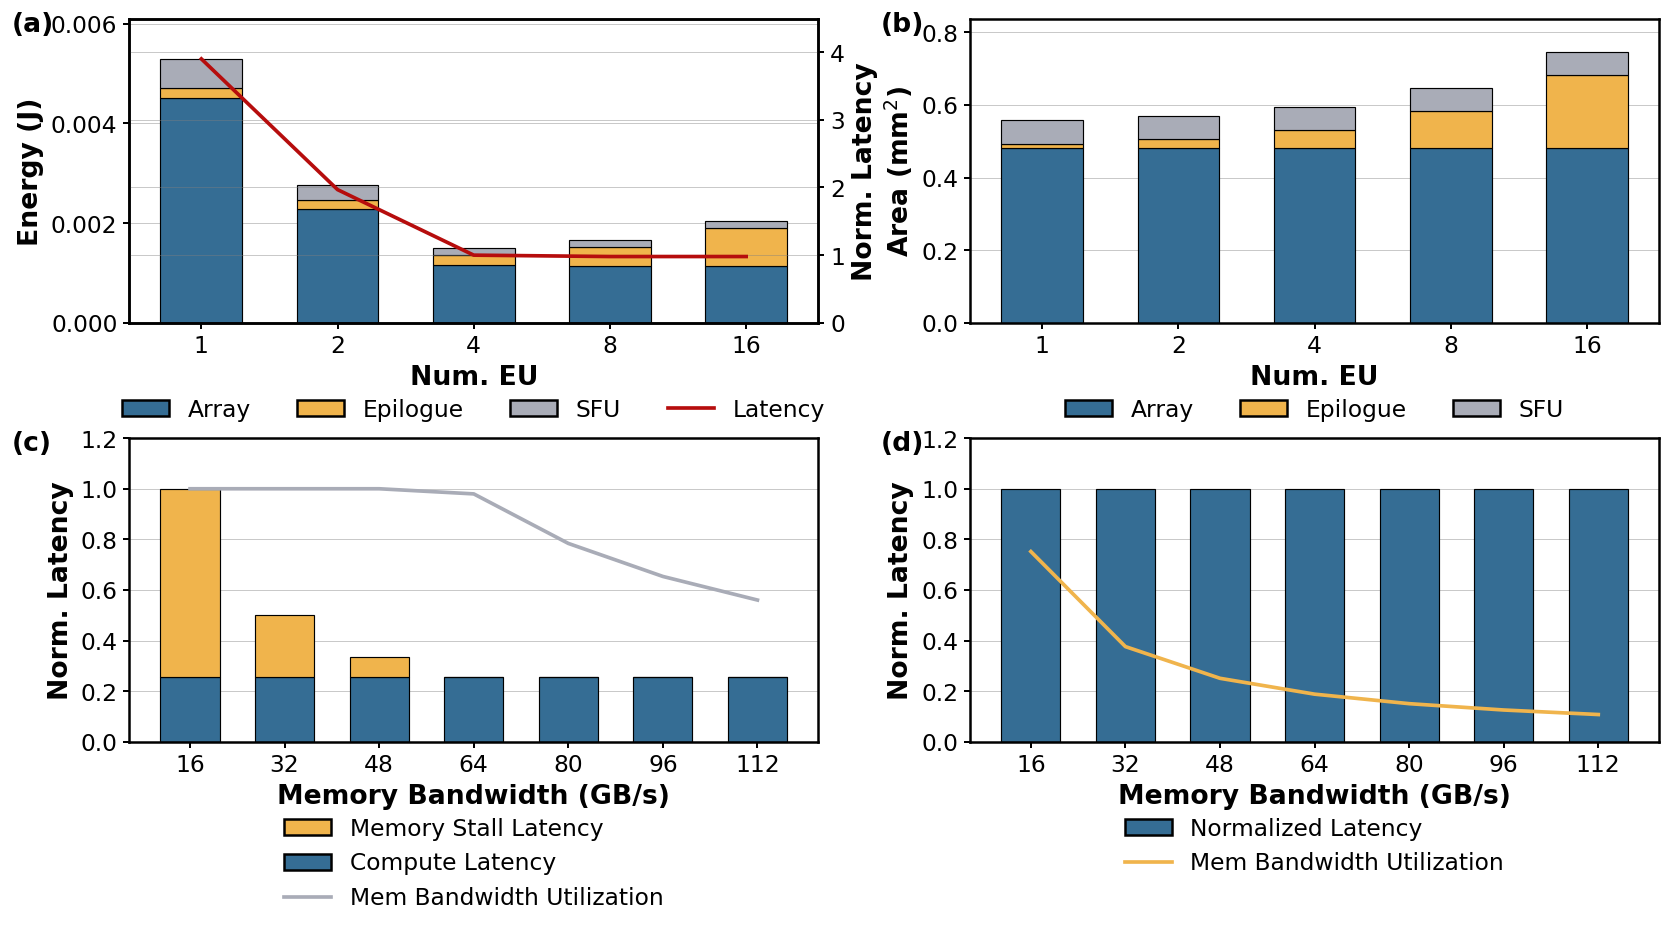

### Figure 8

Saved Figure 8 to `/home/bd199/eva_ae/Eva/simulator/output/notebook_exports/fig8_reproduced.png`

In [70]:
fig8_num_eu = pd.read_csv(require(non_e2e_root / 'fig8_dse' / 'fig8_num_eu.csv'))
fig8_decode_bw = pd.read_csv(require(non_e2e_root / 'fig8_dse' / 'fig8_memory_bandwidth_decode.csv'))
fig8_prefill_bw = pd.read_csv(require(non_e2e_root / 'fig8_dse' / 'fig8_memory_bandwidth_prefill.csv'))
fig8_colors = {
    'array': '#356d94',
    'epilogue': '#f0b44c',
    'sfu': '#a9acb7',
    'latency': '#b60d0d',
    'utilization': '#a9acb7',
}

_fn = ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans']
with plt.rc_context({'font.family': 'sans-serif', 'font.sans-serif': _fn}):
    num_eu = fig8_num_eu['num_eu'].to_numpy()
    x_eu = np.arange(len(num_eu))
    bw_decode = fig8_decode_bw['memory_bandwidth_gbs'].to_numpy()
    bw_prefill = fig8_prefill_bw['memory_bandwidth_gbs'].to_numpy()

    fig, axes = plt.subplots(2, 2, figsize=(15, 7))
    fig.patch.set_facecolor('white')
    fig.subplots_adjust(left=0.08, right=0.93, top=0.96, bottom=0.10, wspace=0.22, hspace=0.38)

    bar_w = 0.6
    axes[0, 0].bar(x_eu, fig8_num_eu['array_energy_j'], width=bar_w, color=fig8_colors['array'], edgecolor='black', linewidth=0.7, label='Array')
    axes[0, 0].bar(x_eu, fig8_num_eu['epilogue_energy_j'], width=bar_w, bottom=fig8_num_eu['array_energy_j'], color=fig8_colors['epilogue'], edgecolor='black', linewidth=0.7, label='Epilogue')
    axes[0, 0].bar(x_eu, fig8_num_eu['sfu_energy_j'], width=bar_w, bottom=fig8_num_eu['array_energy_j'] + fig8_num_eu['epilogue_energy_j'], color=fig8_colors['sfu'], edgecolor='black', linewidth=0.7, label='SFU')
    ax00r = axes[0, 0].twinx()
    ax00r.plot(x_eu, fig8_num_eu['norm_latency'], color=fig8_colors['latency'], linewidth=2.2, label='Latency')
    axes[0, 0].text(-0.17, 0.94, '(a)', transform=axes[0, 0].transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left')
    axes[0, 0].set_xlabel('Num. EU', fontsize=16, fontweight='bold', color='black')
    axes[0, 0].set_ylabel('Energy (J)', fontsize=16, fontweight='bold', color='black')
    ax00r.set_ylabel('Norm. Latency', fontsize=16, fontweight='bold', color='black')
    axes[0, 0].set_xticks(x_eu)
    axes[0, 0].set_xticklabels(num_eu)
    axes[0, 0].set_ylim(0, fig8_num_eu['compute_unit_energy_j'].max() * 1.15)
    ax00r.set_ylim(0, max(fig8_num_eu['norm_latency'].max() * 1.15, 1.2))
    handles_a = [
        Patch(facecolor=fig8_colors['array'], edgecolor='black', linewidth=1.5, label='Array'),
        Patch(facecolor=fig8_colors['epilogue'], edgecolor='black', linewidth=1.5, label='Epilogue'),
        Patch(facecolor=fig8_colors['sfu'], edgecolor='black', linewidth=1.5, label='SFU'),
    ]
    line_a = plt.Line2D([0], [0], color=fig8_colors['latency'], linewidth=2.2, label='Latency')
    axes[0, 0].legend(handles=handles_a + [line_a], loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False, fontsize=14)

    axes[0, 1].bar(x_eu, fig8_num_eu['array_area_mm2'], width=bar_w, color=fig8_colors['array'], edgecolor='black', linewidth=0.7, label='Array')
    axes[0, 1].bar(x_eu, fig8_num_eu['adder_tree_area_mm2'], width=bar_w, bottom=fig8_num_eu['array_area_mm2'], color=fig8_colors['epilogue'], edgecolor='black', linewidth=0.7, label='Epilogue')
    axes[0, 1].bar(x_eu, fig8_num_eu['sfu_area_mm2'], width=bar_w, bottom=fig8_num_eu['array_area_mm2'] + fig8_num_eu['adder_tree_area_mm2'], color=fig8_colors['sfu'], edgecolor='black', linewidth=0.7, label='SFU')
    axes[0, 1].text(-0.13, 0.94, '(b)', transform=axes[0, 1].transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left')
    axes[0, 1].set_xlabel('Num. EU', fontsize=16, fontweight='bold', color='black')
    axes[0, 1].set_ylabel('Area (mm$^2$)', fontsize=16, fontweight='bold', color='black')
    axes[0, 1].set_xticks(x_eu)
    axes[0, 1].set_xticklabels(num_eu)
    axes[0, 1].set_ylim(0, fig8_num_eu['total_area_mm2'].max() * 1.12)
    handles_b = [
        Patch(facecolor=fig8_colors['array'], edgecolor='black', linewidth=1.5, label='Array'),
        Patch(facecolor=fig8_colors['epilogue'], edgecolor='black', linewidth=1.5, label='Epilogue'),
        Patch(facecolor=fig8_colors['sfu'], edgecolor='black', linewidth=1.5, label='SFU'),
    ]
    axes[0, 1].legend(handles=handles_b, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False, fontsize=14)

    axes[1, 0].bar(bw_decode, fig8_decode_bw['compute_latency_norm'], width=10, color=fig8_colors['array'], edgecolor='black', linewidth=0.7)
    axes[1, 0].bar(bw_decode, fig8_decode_bw['mem_stall_latency_norm'], width=10, bottom=fig8_decode_bw['compute_latency_norm'], color=fig8_colors['epilogue'], edgecolor='black', linewidth=0.7)
    axes[1, 0].plot(bw_decode, fig8_decode_bw['mem_bandwidth_utilization'], color=fig8_colors['utilization'], linewidth=2.2)
    axes[1, 0].text(-0.17, 0.94, '(c)', transform=axes[1, 0].transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left')
    axes[1, 0].set_xlabel('Memory Bandwidth (GB/s)', fontsize=16, fontweight='bold', color='black')
    axes[1, 0].set_ylabel('Norm. Latency', fontsize=16, fontweight='bold', color='black')
    axes[1, 0].set_xticks(bw_decode)
    axes[1, 0].set_ylim(0, max(fig8_decode_bw['norm_latency'].max() * 1.15, 1.2))
    handles_c = [
        Patch(facecolor=fig8_colors['epilogue'], edgecolor='black', linewidth=1.5, label='Memory Stall Latency'),
        Patch(facecolor=fig8_colors['array'], edgecolor='black', linewidth=1.5, label='Compute Latency'),
        plt.Line2D([0], [0], color=fig8_colors['utilization'], linewidth=2.2, label='Mem Bandwidth Utilization'),
    ]
    axes[1, 0].legend(handles=handles_c, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=1, frameon=False, fontsize=14)

    axes[1, 1].bar(bw_prefill, fig8_prefill_bw['norm_latency'], width=10, color=fig8_colors['array'], edgecolor='black', linewidth=0.7)
    axes[1, 1].plot(bw_prefill, fig8_prefill_bw['mem_bandwidth_utilization'], color=fig8_colors['epilogue'], linewidth=2.2)
    axes[1, 1].text(-0.13, 0.94, '(d)', transform=axes[1, 1].transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left')
    axes[1, 1].set_xlabel('Memory Bandwidth (GB/s)', fontsize=16, fontweight='bold', color='black')
    axes[1, 1].set_ylabel('Norm. Latency', fontsize=16, fontweight='bold', color='black')
    axes[1, 1].set_xticks(bw_prefill)
    axes[1, 1].set_ylim(0, 1.2)
    handles_d = [
        Patch(facecolor=fig8_colors['array'], edgecolor='black', linewidth=1.5, label='Normalized Latency'),
        plt.Line2D([0], [0], color=fig8_colors['epilogue'], linewidth=2.2, label='Mem Bandwidth Utilization'),
    ]
    axes[1, 1].legend(handles=handles_d, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=1, frameon=False, fontsize=14)

    for ax in list(axes.flat) + [ax00r]:
        ax.set_facecolor('white')
        ax.tick_params(axis='both', labelsize=14, colors='black', width=1.2)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)
            spine.set_color('black')
        ax.yaxis.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
        ax.set_axisbelow(True)

    fig8_path = save_figure(fig, 'fig8_reproduced.png')
    plt.show()
display(Markdown('### Figure 8'))
display(Markdown(f'Saved Figure 8 to `{fig8_path}`'))

### Fig. 9 -- FC Decode Latency and Energy
Latency and energy for EVA vs baselines on FC layers, batch size 1, decoding phase, across LLaMA models.

`python -m simulator.main --study fig9_fc --output-dir simulator/output`

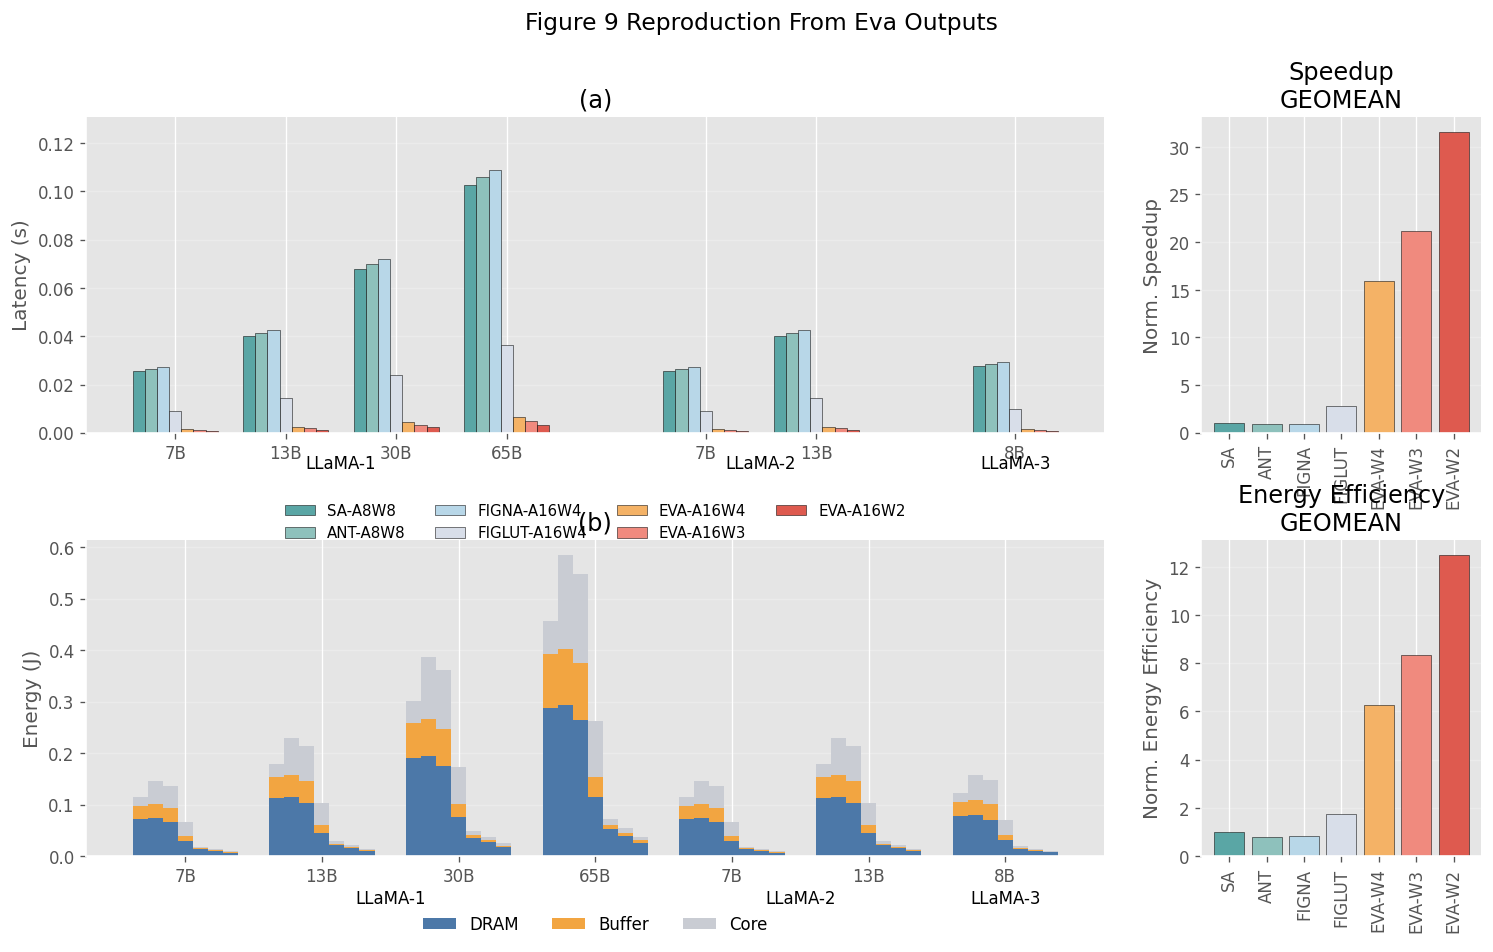

Saved Figure 9 to `/home/bd199/eva_ae/Eva/simulator/output/notebook_exports/figure9_reproduced.png`

In [71]:
fig9_aggregated_csv = require(fig9_root / 'aggregated_sequence1.csv')
figure9_path = export_root / 'figure9_reproduced.png'
fig = plot_fig9_from_aggregated_csv(fig9_aggregated_csv, figure9_path)
plt.show(fig)
display(Markdown(f'Saved Figure 9 to `{figure9_path}`'))

### Fig. 10 -- Area and Power Breakdown
Breakdown of EVA area and power (systolic array, epilogue, SFU, SRAM, DRAM).

`python -m simulator.main --study fig10_hw --output-dir simulator/output`

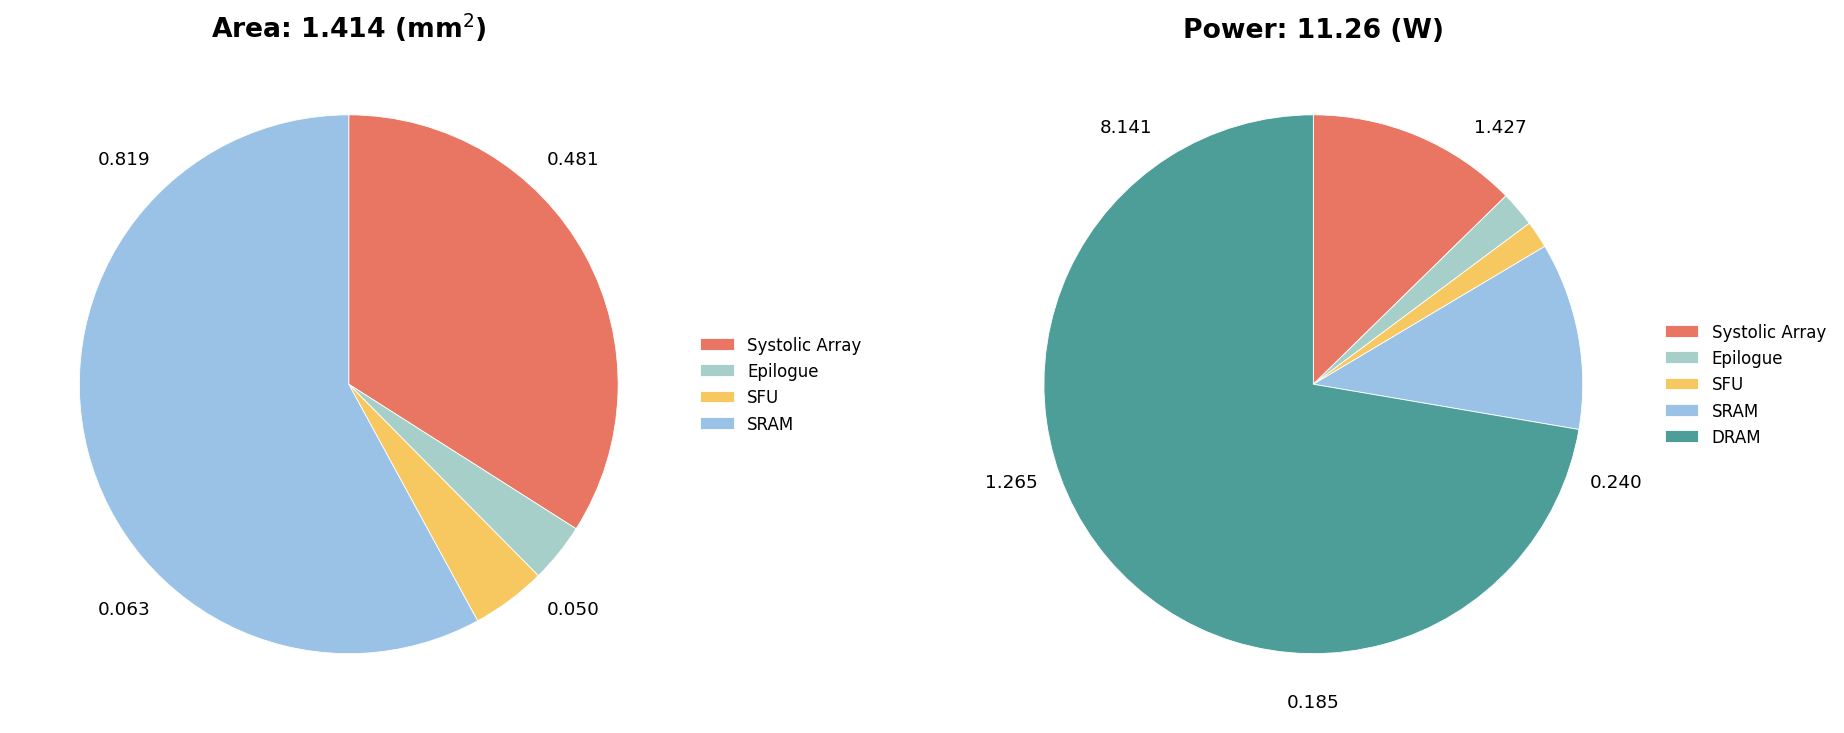

### Figure 10

Saved Figure 10 to `/home/bd199/eva_ae/Eva/simulator/output/notebook_exports/fig10_reproduced.png`

In [72]:
fig10_area = pd.read_csv(require(non_e2e_root / 'fig10_hw' / 'fig10_area_breakdown.csv'))
fig10_power = pd.read_csv(require(non_e2e_root / 'fig10_hw' / 'fig10_power_breakdown.csv'))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
area_labels = ['Systolic Array', 'Epilogue', 'SFU', 'SRAM']
area_values = fig10_area['area_mm2'].tolist()
area_colors = [COLOR_MAP['EVA-A16W4'], '#a7cfc9', '#f6c85f', '#9ac2e6']
axes[0].pie(area_values, colors=area_colors, startangle=90, counterclock=False, wedgeprops={'edgecolor': 'white'})
axes[0].set_title(f'Area: {fig10_area["total_area_mm2"].iloc[0]:.3f} (mm$^2$)', fontsize=16, fontweight='bold')
axes[0].legend(area_labels, loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)
for idx, value in enumerate(area_values):
    axes[0].text(1.18 * np.cos(np.deg2rad(90 - (idx + 0.5) * 360 / len(area_values))), 1.18 * np.sin(np.deg2rad(90 - (idx + 0.5) * 360 / len(area_values))), f'{value:.3f}', ha='center', va='center', fontsize=11)

power_labels = ['Systolic Array', 'Epilogue', 'SFU', 'SRAM', 'DRAM']
power_values = fig10_power['power_w'].tolist()
power_colors = [COLOR_MAP['EVA-A16W4'], '#a7cfc9', '#f6c85f', '#9ac2e6', '#4d9e98']
axes[1].pie(power_values, colors=power_colors, startangle=90, counterclock=False, wedgeprops={'edgecolor': 'white'})
axes[1].set_title(f'Power: {fig10_power["total_power_w"].iloc[0]:.2f} (W)', fontsize=16, fontweight='bold')
axes[1].legend(power_labels, loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)
for idx, value in enumerate(power_values):
    axes[1].text(1.18 * np.cos(np.deg2rad(90 - (idx + 0.5) * 360 / len(power_values))), 1.18 * np.sin(np.deg2rad(90 - (idx + 0.5) * 360 / len(power_values))), f'{value:.3f}', ha='center', va='center', fontsize=11)
fig10_path = save_figure(fig, 'fig10_reproduced.png')
plt.show()
display(Markdown('### Figure 10'))
display(Markdown(f'Saved Figure 10 to `{fig10_path}`'))

### Fig. 11 -- Batch Scaling
Latency and energy vs batch size on LLaMA-2-7B.

`python -m simulator.main --study fig11_batch --output-dir simulator/output`

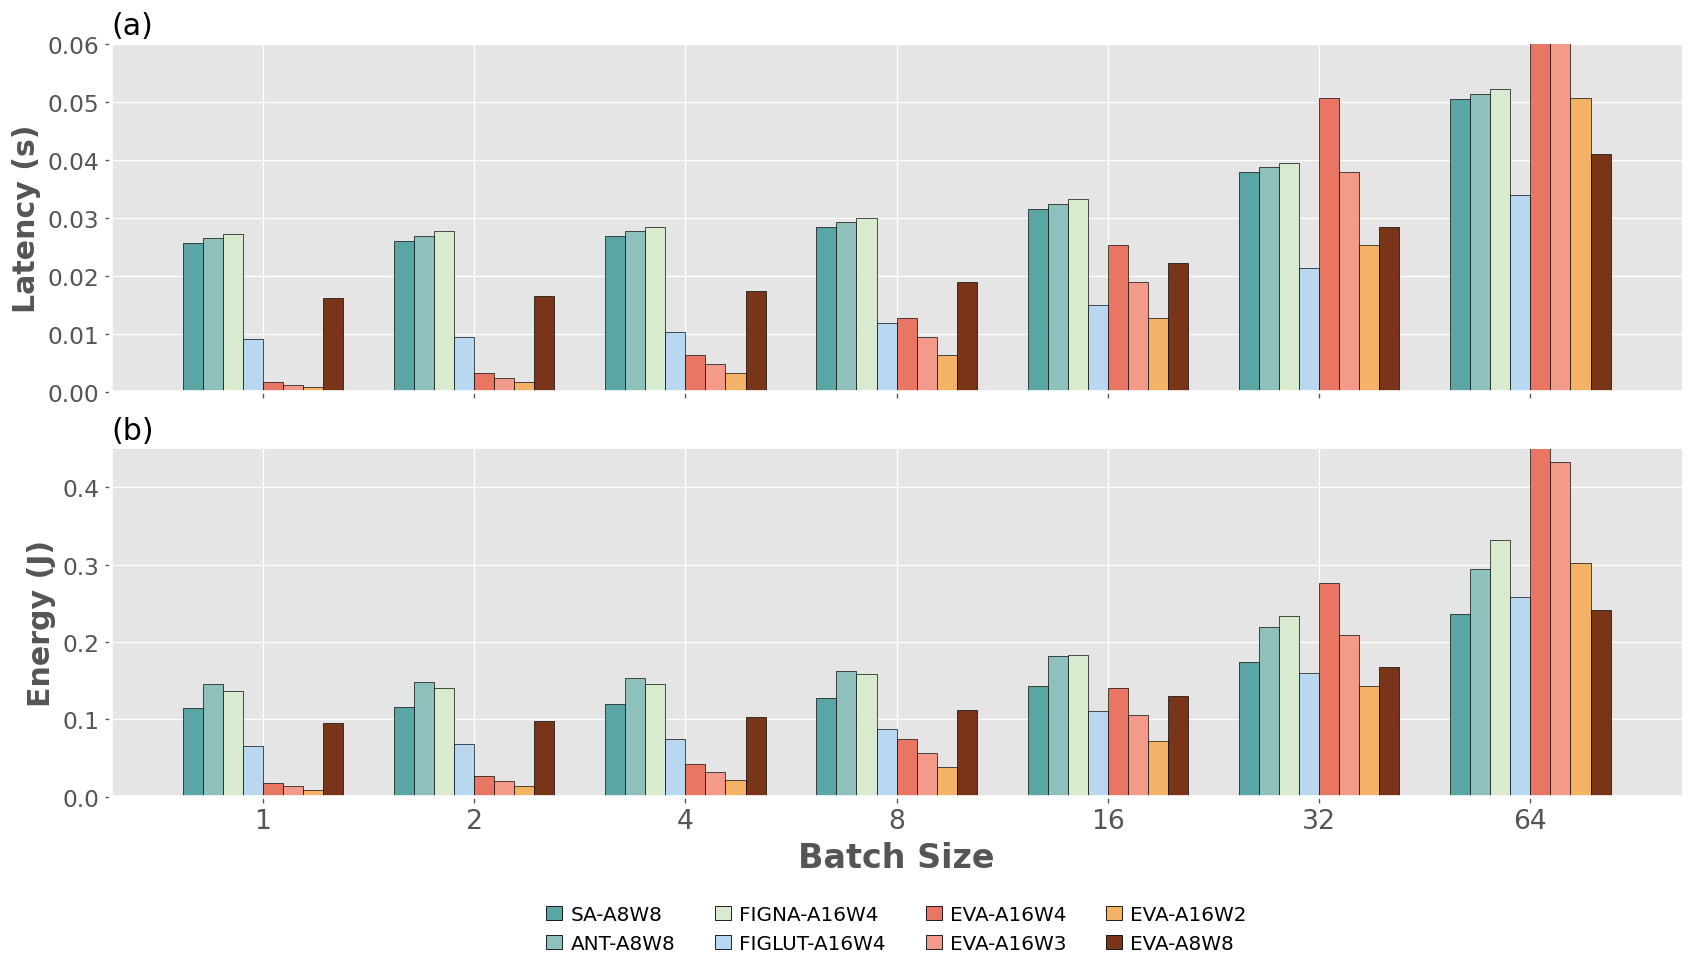

### Figure 11

Saved Figure 11 to `/home/bd199/eva_ae/Eva/simulator/output/notebook_exports/fig11_reproduced.png`

In [73]:
fig11 = pd.read_csv(require(non_e2e_root / 'fig11_batch' / 'fig11_batch_scaling.csv'))
fig11 = fig11[fig11['batch_size'].isin([1, 2, 4, 8, 16, 32, 64])].copy()
fig11_order = ['SA-A8W8', 'ANT-A8W8', 'FIGNA-A16W4', 'FIGLUT-A16W4', 'EVA-A16W4', 'EVA-A16W3', 'EVA-A16W2', 'EVA-A8W8']
fig11 = fig11[fig11['paper_label'].isin(fig11_order)].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True, sharex=True)
batch_sizes = sorted(fig11['batch_size'].unique())
x = np.arange(len(batch_sizes))
bar_width = 0.095
for idx, label in enumerate(fig11_order):
    subset = fig11[fig11['paper_label'] == label].sort_values('batch_size')
    offset = (idx - (len(fig11_order) - 1) / 2) * bar_width
    color = COLOR_MAP[label]
    axes[0].bar(x + offset, subset['total_time_s'], width=bar_width, color=color, edgecolor='black', linewidth=0.4, label=label)
    axes[1].bar(x + offset, subset['total_energy_j'], width=bar_width, color=color, edgecolor='black', linewidth=0.4, label=label)
axes[0].set_ylabel('Latency (s)', fontsize=18, fontweight='bold')
axes[0].set_title('(a)', loc='left', fontsize=18)
axes[0].set_ylim(0, 0.06)
axes[1].set_ylabel('Energy (J)', fontsize=18, fontweight='bold')
axes[1].set_title('(b)', loc='left', fontsize=18)
axes[1].set_xlabel('Batch Size', fontsize=20, fontweight='bold')
axes[1].set_ylim(0, 0.45)
axes[1].set_xticks(x)
axes[1].set_xticklabels(batch_sizes, fontsize=16)
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(2.2)
    ax.tick_params(axis='y', labelsize=14)
handles = [Patch(facecolor=COLOR_MAP[label], edgecolor='black', label=label) for label in fig11_order]
axes[1].legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.26), ncol=4, frameon=False, fontsize=12, handlelength=0.8, handletextpad=0.4)
fig11_path = save_figure(fig, 'fig11_reproduced.png')
plt.show()
display(Markdown('### Figure 11'))
display(Markdown(f'Saved Figure 11 to `{fig11_path}`'))

### Fig. 12 -- End-to-End Dense (Llama-2-7B on Dolly)
(a) Prefill time, (b) decoding time, (c) decode/total ratio, (d) total time.

`python -m simulator.main --study e2e --output-dir simulator/output --execution-mode full --scenarios fig12_llama2`

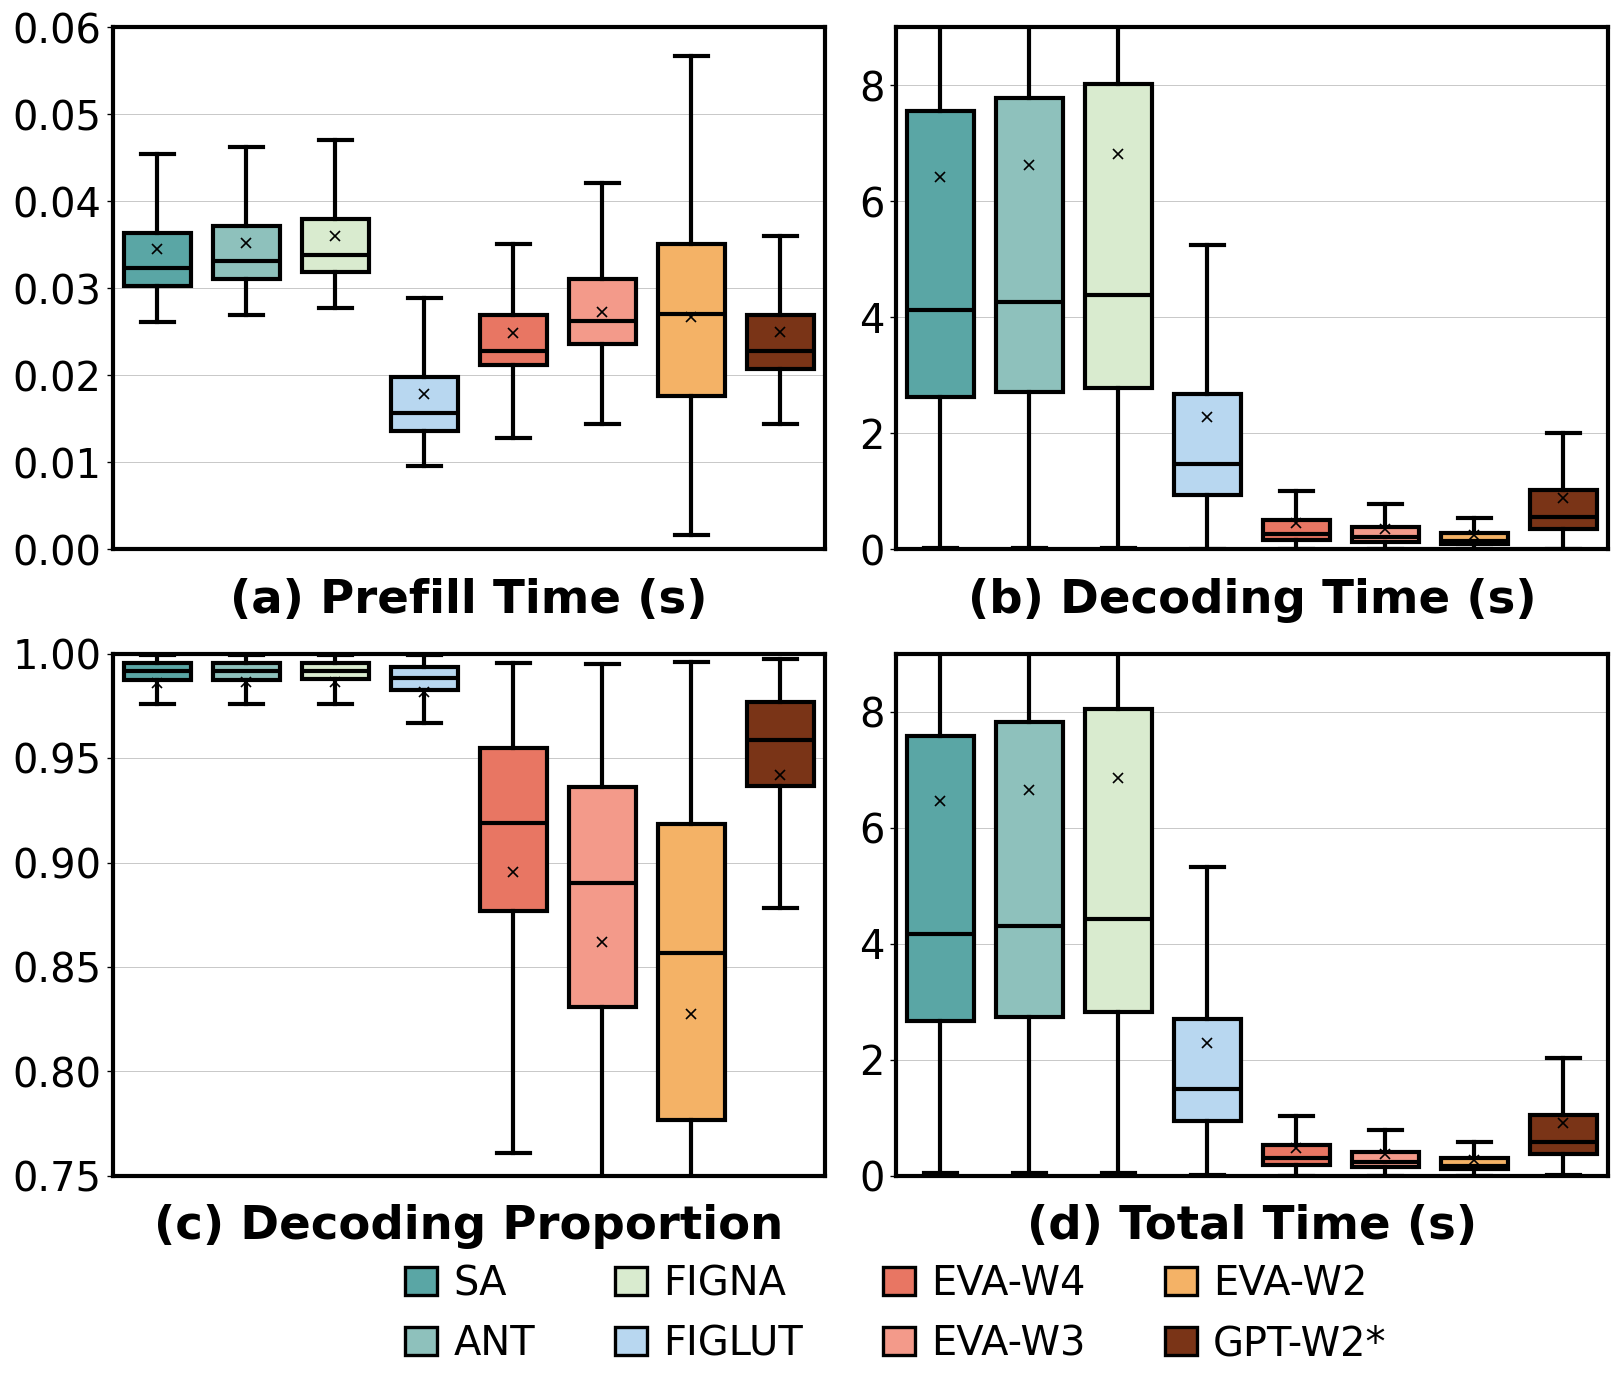

### Figure 12

Saved Figure 12 to `/home/bd199/eva_ae/Eva/simulator/output/notebook_exports/fig12_reproduced.png`

In [74]:
trace_linear = pd.read_csv(require(e2e_root / 'fig12_llama2' / 'trace_results_llama_2_7b_dolly_creative_writing.csv'))
trace_methods = [
    ('systolic_array', 'SA'),
    ('ant', 'ANT'),
    ('figna', 'FIGNA'),
    ('figlut_4', 'FIGLUT'),
    ('vqarray_4_decode', 'EVA-W4'),
    ('vqarray_3_decode', 'EVA-W3'),
    ('vqarray_2_decode', 'EVA-W2'),
    ('vqarray_2_gptvq_decode', 'GPT-W2*'),
]
fig12_metrics = {
    '(a) Prefill Time (s)': [],
    '(b) Decoding Time (s)': [],
    '(c) Decoding Proportion': [],
    '(d) Total Time (s)': [],
}
fig12_labels = []
fig12_colors = []
for method, label in trace_methods:
    prefill = trace_linear[f'prefill_{method}_time_s']
    decode = trace_linear[f'decode_{method}_time_s']
    total = prefill + decode
    fig12_metrics['(a) Prefill Time (s)'].append(prefill.to_numpy())
    fig12_metrics['(b) Decoding Time (s)'].append(decode.to_numpy())
    fig12_metrics['(c) Decoding Proportion'].append((decode / total).to_numpy())
    fig12_metrics['(d) Total Time (s)'].append(total.to_numpy())
    fig12_labels.append(label)
    fig12_colors.append(COLOR_MAP.get(label, '#888888'))

_fn = ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans']
with plt.rc_context({'font.family': 'sans-serif', 'font.sans-serif': _fn}):
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.patch.set_facecolor('white')
    fig.subplots_adjust(left=0.09, right=0.98, top=0.99, bottom=0.12, wspace=0.10, hspace=0.20)
    for ax, (title, arrays) in zip(axes.flatten(), fig12_metrics.items()):
        ax.set_facecolor('white')
        bp = ax.boxplot(arrays, patch_artist=True, widths=0.75, showmeans=True, showfliers=False, meanprops={'marker': 'x', 'markeredgecolor': 'black', 'markersize': 6})
        for patch, color in zip(bp['boxes'], fig12_colors):
            patch.set_facecolor(color)
            patch.set_edgecolor('black')
            patch.set_linewidth(2.5)
        for key in ['whiskers', 'caps', 'medians']:
            for artist in bp[key]:
                artist.set_color('black')
                artist.set_linewidth(2.5)
        ax.set_title(title, fontsize=28, fontweight='bold', y=-0.14)
        ax.set_xticks([])
        ax.tick_params(axis='y', labelsize=24, colors='black')
        ax.tick_params(axis='x', colors='black')
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2.5)
            spine.set_color('black')
        ax.yaxis.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
        ax.set_axisbelow(True)
        if 'Prefill' in title:
            ax.set_ylim(0, 0.06)
        elif 'Decoding Time' in title:
            ax.set_ylim(0, 9)
        elif 'Proportion' in title:
            ax.set_ylim(0.75, 1.0)
        elif 'Total' in title:
            ax.set_ylim(0, 9)
    handles = [Patch(facecolor=color, edgecolor='black', linewidth=2.0, label=label) for color, label in zip(fig12_colors, fig12_labels)]
    leg = axes[1, 0].legend(handles=handles, loc='upper center', bbox_to_anchor=(1.1, -0.10), ncol=4, frameon=False, fontsize=24, handlelength=0.8, handletextpad=0.4)
    fig12_path = save_figure(fig, 'fig12_reproduced.png')
    plt.show()
display(Markdown('### Figure 12'))
display(Markdown(f'Saved Figure 12 to `{fig12_path}`'))

### Fig. 13 -- End-to-End MoE

`python -m simulator.main --study e2e --output-dir simulator/output --execution-mode full --scenarios fig13_moe`

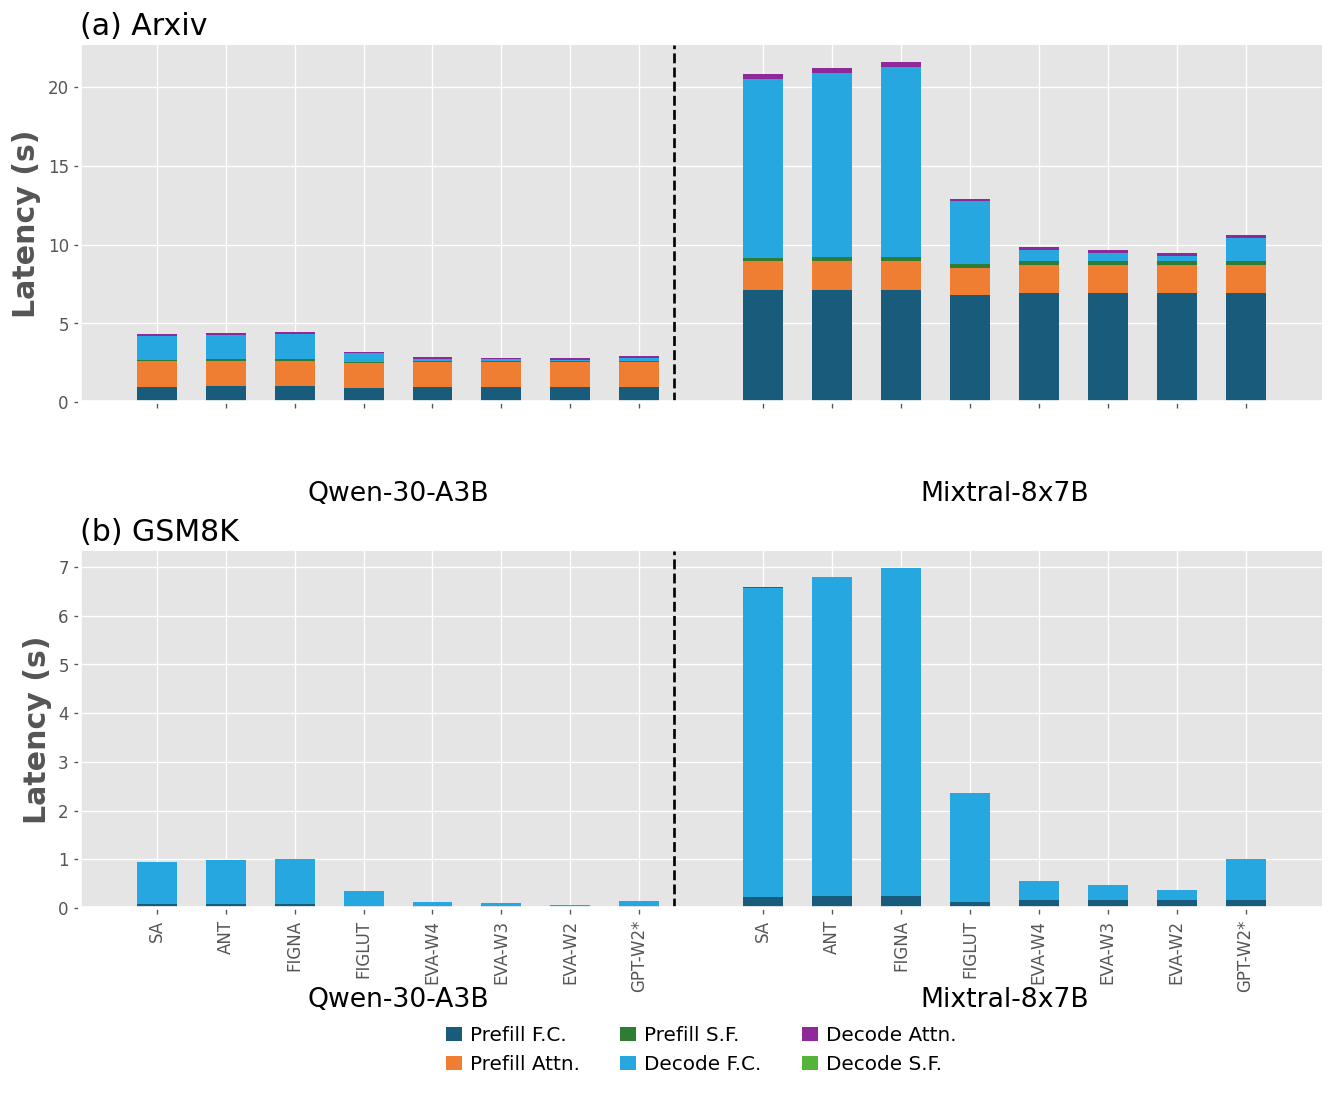

Saved Fig. 13 (stage2) to `/home/bd199/eva_ae/Eva/simulator/output/notebook_exports/fig13_stage2_reproduced.png`

In [75]:
fig13_s2_path = e2e_root / 'fig13_moe.csv'
if fig13_s2_path.exists():
    fig13_s2 = pd.read_csv(fig13_s2_path)
    fig13_s2 = fig13_s2[fig13_s2['paper_label'].isin(PAPER_METHOD_ORDER)].copy()
    fig13_s2['paper_label'] = pd.Categorical(fig13_s2['paper_label'], PAPER_METHOD_ORDER, ordered=True)
    stack_columns = ['prefill_fc_s', 'prefill_attention_s', 'prefill_sfu_s', 'decode_fc_s', 'decode_attention_s', 'decode_sfu_s']
    stack_labels = ['Prefill F.C.', 'Prefill Attn.', 'Prefill S.F.', 'Decode F.C.', 'Decode Attn.', 'Decode S.F.']
    stack_colors = ['#185b7a', '#ef7d32', '#2e7d32', '#27a7df', '#8e2999', '#56b33a']
    model_order = ['qwen3_30b_a3b', 'mixtral_8x7b']

    fig, axes = plt.subplots(2, 1, figsize=(11, 9), constrained_layout=True, sharex=True)
    for ax, dataset_key, title in zip(axes, ['arxiv', 'gsm8k'], ['(a) Arxiv', '(b) GSM8K']):
        positions = []
        labels = []
        cursor = 0
        for model_key in model_order:
            subset = fig13_s2[(fig13_s2['dataset'] == dataset_key) & (fig13_s2['model'] == model_key)].sort_values('paper_label')
            for _, row in subset.iterrows():
                positions.append(cursor)
                labels.append(row['paper_label'])
                bottom = 0.0
                for color, column in zip(stack_colors, stack_columns):
                    ax.bar(cursor, row[column], bottom=bottom, color=color, width=0.58)
                    bottom += row[column]
                cursor += 1
            if model_key != model_order[-1]:
                ax.axvline(cursor - 0.5, color='black', linestyle='--', linewidth=1.6)
                cursor += 0.8
        ax.set_ylabel('Latency (s)', fontsize=18, fontweight='bold')
        ax.set_title(title, loc='left', fontsize=18)
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=90, fontsize=10)
        for spine in ax.spines.values():
            spine.set_linewidth(2.2)
        ax.text(3.5, -0.22 * ax.get_ylim()[1], 'Qwen-30-A3B', ha='center', va='top', fontsize=16, transform=ax.transData)
        ax.text(12.3, -0.22 * ax.get_ylim()[1], 'Mixtral-8x7B', ha='center', va='top', fontsize=16, transform=ax.transData)
    legend_handles = [Patch(facecolor=color, edgecolor='none', label=label) for color, label in zip(stack_colors, stack_labels)]
    axes[1].legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.28), ncol=3, frameon=False, fontsize=12, handlelength=0.8, handletextpad=0.4)
    fig13_s2_export = save_figure(fig, 'fig13_stage2_reproduced.png')
    plt.show()
    display(Markdown(f'Saved Fig. 13 (stage2) to `{fig13_s2_export}`'))
else:
    display(Markdown('`fig13_moe.csv` not found -- run the fig13_moe scenario first.'))

### Fig. 14 -- Codebook Index Analysis
(a) Utilization vs output dimension, (b) average count per output channel.

`python -m simulator.main --study fig14_index --output-dir simulator/output`

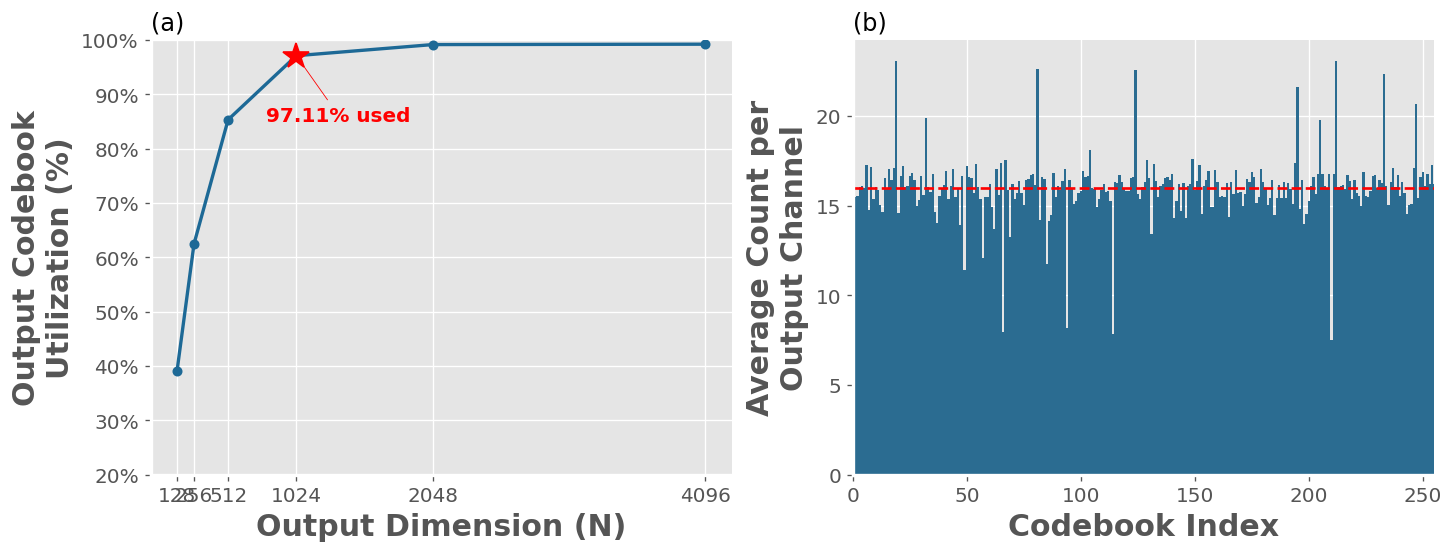

### Figure 14

Saved Figure 14 to `/home/bd199/eva_ae/Eva/simulator/output/notebook_exports/fig14_reproduced.png`

In [76]:
histogram = pd.read_csv(require(non_e2e_root / 'fig14_index' / 'fig14_index_count_histogram_avg.csv'))
utilization = pd.read_csv(require(non_e2e_root / 'fig14_index' / 'fig14_unique_indices_per_tile_avg.csv'))
utilization['utilization_pct'] = utilization['avg_unique_indices'] / 256.0 * 100.0
mean_count = histogram['avg_count'].mean()
annot_row = utilization[utilization['tile_size'] == 1024].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].plot(utilization['tile_size'], utilization['utilization_pct'], color='#1d6996', marker='o', linewidth=2.0, markersize=5)
axes[0].plot([annot_row['tile_size']], [annot_row['utilization_pct']], marker='*', color='red', markersize=16)
axes[0].annotate(
    f"{annot_row['utilization_pct']:.2f}% used",
    xy=(annot_row['tile_size'], annot_row['utilization_pct']),
    xytext=(annot_row['tile_size'] * 0.78, annot_row['utilization_pct'] - 12),
    color='red',
    fontsize=12,
    fontweight='bold',
    arrowprops={'arrowstyle': '-', 'color': 'red'},
)
axes[0].set_title('(a)', loc='left')
axes[0].set_ylabel('Output Codebook\nUtilization (%)', fontsize=18, fontweight='bold')
axes[0].set_xlabel('Output Dimension (N)', fontsize=18, fontweight='bold')
axes[0].set_xticks(utilization['tile_size'])
axes[0].set_xticklabels(utilization['tile_size'].astype(int), fontsize=12)
axes[0].set_ylim(20, 100)
axes[0].yaxis.set_major_formatter(PercentFormatter())

axes[1].bar(histogram['index'], histogram['avg_count'], width=1.0, color='#2b6c91')
axes[1].axhline(mean_count, color='red', linestyle='--', linewidth=1.6)
axes[1].set_title('(b)', loc='left')
axes[1].set_ylabel('Average Count per\nOutput Channel', fontsize=18, fontweight='bold')
axes[1].set_xlabel('Codebook Index', fontsize=18, fontweight='bold')
axes[1].set_xlim(0, 255)
axes[1].set_ylim(0, max(24, histogram['avg_count'].max() * 1.05))
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
    ax.tick_params(labelsize=12)
fig14_path = save_figure(fig, 'fig14_reproduced.png')
plt.show()
display(Markdown('### Figure 14'))
display(Markdown(f'Saved Figure 14 to `{fig14_path}`'))

In [77]:
generated_files = sorted(path.name for path in export_root.iterdir())
display(Markdown('Generated artifacts:\n' + '\n'.join(f'- `{name}`' for name in generated_files)))

Generated artifacts:
- `fig10_reproduced.png`
- `fig11_reproduced.png`
- `fig12_llama2_full_arxiv_gsm8k_reproduced.png`
- `fig12_reproduced.png`
- `fig13_reproduced.png`
- `fig13_stage2_reproduced.png`
- `fig14_reproduced.png`
- `fig8_reproduced.png`
- `figure9_reproduced.png`
- `table_ix_reproduced.csv`
- `table_vi_reproduced.csv`
- `table_vii_reproduced.csv`
- `table_viii_reproduced.csv`